MODEL IMPROVEMENT TECHNIQUES (60 mins)

## 3.1 How to Fix Overfitting

### Indian Analogy: The Ratta Maar Student 📚

**Overfitting** = Student who memorizes answers without understanding
```
Training (Ratta):    "What is photosynthesis?" → Perfect answer (memorized)
New Question:        "How does photosynthesis affect climate?" → FAILS!

Training Accuracy:   99%
Test Accuracy:       50%

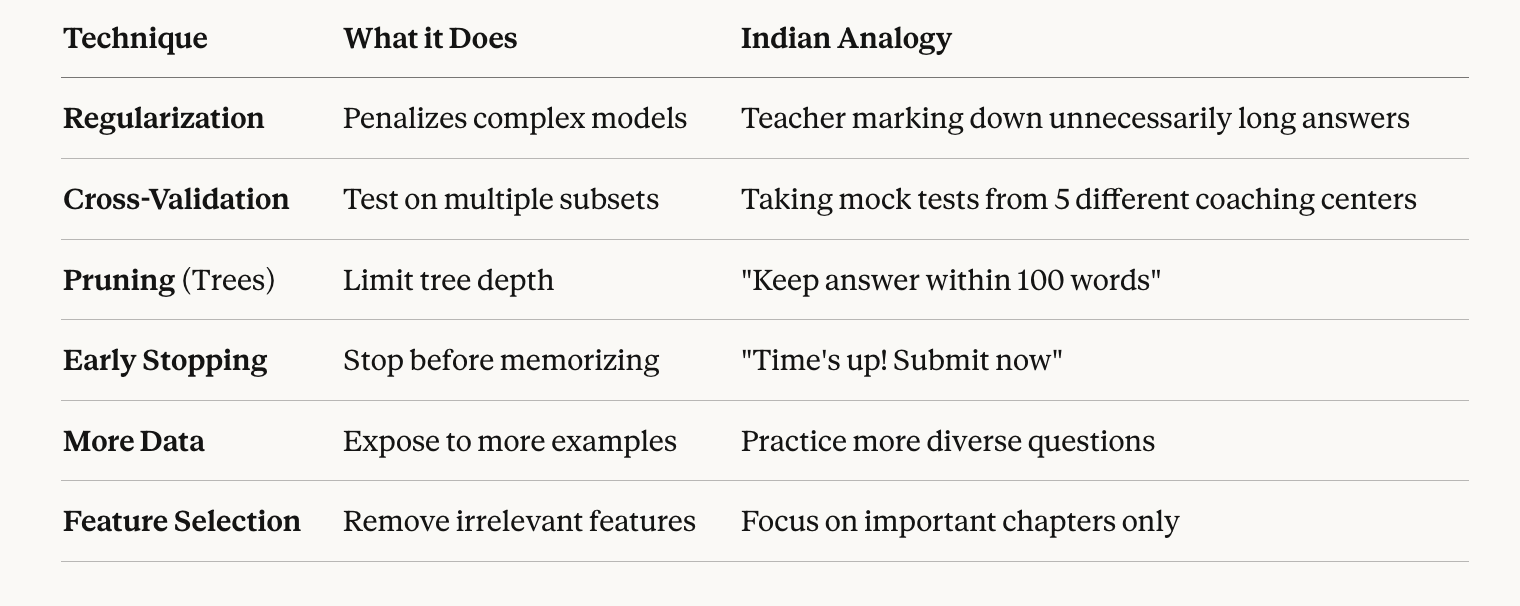

=== TECHNIQUE 1: REGULARIZATION ===
No Regularization - Train: 0.9500, Test: 0.9300
L2 (Ridge)        - Train: 0.9550, Test: 0.9300
L1 (Lasso)        - Train: 0.9525, Test: 0.9400

=== TECHNIQUE 2: PRUNING (Decision Trees) ===
No Pruning - Train: 1.0000, Test: 0.8200
With Pruning - Train: 0.9250, Test: 0.8200
No Pruning Depth: 8, Pruned Depth: 5

=== TECHNIQUE 3: ENSEMBLE (Random Forest) ===
Random Forest - Train: 0.9850, Test: 0.9000

=== TECHNIQUE 4: CROSS-VALIDATION ===
5-Fold CV Scores: [0.9  0.87 0.88 0.8  0.8 ]
Mean: 0.8500 ± 0.0420

=== TECHNIQUE 5: LEARNING CURVE ANALYSIS ===


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

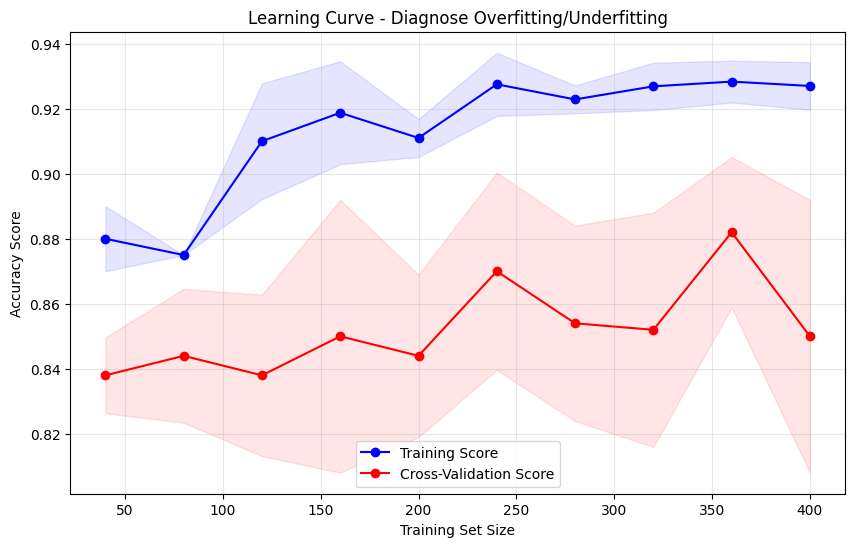

Interpretation:
• If train >> test: OVERFITTING - need more data or simpler model
• If both low: UNDERFITTING - need more features or complex model
• If train ≈ test (both high): GOOD FIT!


In [1]:
# ============================================================
# TECHNIQUES TO FIX OVERFITTING
# ============================================================

from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create sample data
np.random.seed(42)
n = 500
X = np.random.randn(n, 10)  # 10 features
y = (X[:, 0] + X[:, 1] * 2 + X[:, 2] * 0.5 + np.random.randn(n) * 0.5 > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === TECHNIQUE 1: REGULARIZATION ===
print("=== TECHNIQUE 1: REGULARIZATION ===")

# Without regularization
model_no_reg = LogisticRegression(penalty=None, max_iter=1000)
model_no_reg.fit(X_train, y_train)

# With L2 regularization (Ridge)
model_l2 = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
model_l2.fit(X_train, y_train)

# With L1 regularization (Lasso) - does feature selection
model_l1 = LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=1000)
model_l1.fit(X_train, y_train)

print(f"No Regularization - Train: {model_no_reg.score(X_train, y_train):.4f}, Test: {model_no_reg.score(X_test, y_test):.4f}")
print(f"L2 (Ridge)        - Train: {model_l2.score(X_train, y_train):.4f}, Test: {model_l2.score(X_test, y_test):.4f}")
print(f"L1 (Lasso)        - Train: {model_l1.score(X_train, y_train):.4f}, Test: {model_l1.score(X_test, y_test):.4f}")

# === TECHNIQUE 2: PRUNING (for Decision Trees) ===
print("\n=== TECHNIQUE 2: PRUNING (Decision Trees) ===")

# Without pruning (will overfit)
tree_no_prune = DecisionTreeClassifier(random_state=42)
tree_no_prune.fit(X_train, y_train)

# With pruning
tree_pruned = DecisionTreeClassifier(
    max_depth=5,           # Limit depth
    min_samples_split=20,  # Min samples to split
    min_samples_leaf=10,   # Min samples in leaf
    random_state=42
)
tree_pruned.fit(X_train, y_train)

print(f"No Pruning - Train: {tree_no_prune.score(X_train, y_train):.4f}, Test: {tree_no_prune.score(X_test, y_test):.4f}")
print(f"With Pruning - Train: {tree_pruned.score(X_train, y_train):.4f}, Test: {tree_pruned.score(X_test, y_test):.4f}")
print(f"No Pruning Depth: {tree_no_prune.get_depth()}, Pruned Depth: {tree_pruned.get_depth()}")

# === TECHNIQUE 3: ENSEMBLE METHODS ===
print("\n=== TECHNIQUE 3: ENSEMBLE (Random Forest) ===")

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

print(f"Random Forest - Train: {rf_model.score(X_train, y_train):.4f}, Test: {rf_model.score(X_test, y_test):.4f}")

# === TECHNIQUE 4: CROSS-VALIDATION ===
print("\n=== TECHNIQUE 4: CROSS-VALIDATION ===")

cv_scores = cross_val_score(tree_pruned, X, y, cv=5)
print(f"5-Fold CV Scores: {np.round(cv_scores, 4)}")
print(f"Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# === TECHNIQUE 5: LEARNING CURVE ===
print("\n=== TECHNIQUE 5: LEARNING CURVE ANALYSIS ===")

train_sizes, train_scores, test_scores = learning_curve(
    tree_pruned, X, y, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'b-o', label='Training Score')
plt.plot(train_sizes, test_scores.mean(axis=1), 'r-o', label='Cross-Validation Score')
plt.fill_between(train_sizes, 
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), 
                 alpha=0.1, color='blue')
plt.fill_between(train_sizes, 
                 test_scores.mean(axis=1) - test_scores.std(axis=1),
                 test_scores.mean(axis=1) + test_scores.std(axis=1), 
                 alpha=0.1, color='red')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.title('Learning Curve - Diagnose Overfitting/Underfitting')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('learning_curve.png', dpi=150)
plt.show()

print("Interpretation:")
print("• If train >> test: OVERFITTING - need more data or simpler model")
print("• If both low: UNDERFITTING - need more features or complex model")
print("• If train ≈ test (both high): GOOD FIT!")

## 3.2 How to Fix Underfitting

### Indian Analogy: The Unprepared Student 📖

**Underfitting** = Student who barely studied
```
Training:    Poor understanding
Test:        Also poor

Training Accuracy:   55%
Test Accuracy:       53%

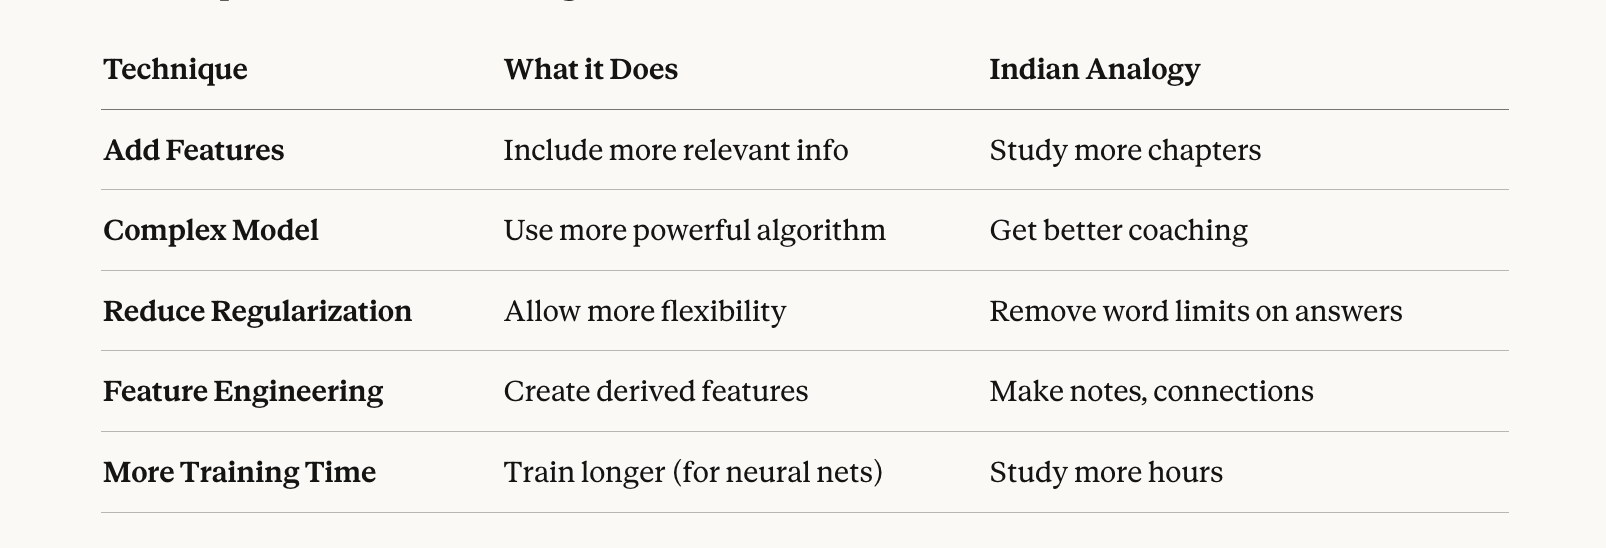

In [3]:
# ============================================================
# COMPLETE MODEL IMPROVEMENT PIPELINE
# ============================================================

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import pandas as pd

# Create sample classification problem
np.random.seed(42)
n = 1000
X = pd.DataFrame({
    'feature1': np.random.randn(n),
    'feature2': np.random.randn(n),
    'feature3': np.random.randn(n),
    'feature4': np.random.randn(n),
})
y = ((X['feature1'] + X['feature2']**2 - X['feature3']*X['feature4'] + 
      np.random.randn(n)*0.5) > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("="*70)
print("STEP 1: BASELINE MODEL")
print("="*70)

baseline = LogisticRegression(random_state=42)
baseline.fit(X_train, y_train)
baseline_score = accuracy_score(y_test, baseline.predict(X_test))
print(f"Baseline Logistic Regression: {baseline_score:.4f}")

print("\n" + "="*70)
print("STEP 2: TRY DIFFERENT ALGORITHMS")
print("="*70)

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
}

results = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    results.append({
        'Model': name,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })
    print(f"{name}: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

results_df = pd.DataFrame(results).sort_values('CV Mean', ascending=False)
print(f"\nBest Model: {results_df.iloc[0]['Model']}")

print("\n" + "="*70)
print("STEP 3: FEATURE ENGINEERING")
print("="*70)

# Add polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Original features: {X_train.shape[1]}")
print(f"After polynomial features: {X_train_poly.shape[1]}")

# Try with polynomial features
model_poly = LogisticRegression(random_state=42, max_iter=1000)
cv_scores_poly = cross_val_score(model_poly, X_train_poly, y_train, cv=5)
print(f"Logistic + Polynomial: {cv_scores_poly.mean():.4f} ± {cv_scores_poly.std():.4f}")

print("\n" + "="*70)
print("STEP 4: HYPERPARAMETER TUNING (GridSearchCV)")
print("="*70)

# Tune Random Forest (best model)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

print("\n" + "="*70)
print("STEP 5: FINAL EVALUATION")
print("="*70)

# Train final model with best parameters
final_model = grid_search.best_estimator_
y_pred = final_model.predict(X_test)

print(f"\nFinal Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Improvement over baseline: {(accuracy_score(y_test, y_pred) - baseline_score)*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance
print("\nTop Features:")
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(importance_df.to_string(index=False))

STEP 1: BASELINE MODEL
Baseline Logistic Regression: 0.7450

STEP 2: TRY DIFFERENT ALGORITHMS
Logistic Regression: 0.7350 ± 0.0330
Decision Tree: 0.7462 ± 0.0179
Random Forest: 0.8075 ± 0.0047
Gradient Boosting: 0.8200 ± 0.0115

Best Model: Gradient Boosting

STEP 3: FEATURE ENGINEERING
Original features: 4
After polynomial features: 14
Logistic + Polynomial: 0.8812 ± 0.0137

STEP 4: HYPERPARAMETER TUNING (GridSearchCV)
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.8350

STEP 5: FINAL EVALUATION

Final Test Accuracy: 0.8750
Improvement over baseline: 13.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.72      0.80        69
           1       0.87      0.95      0.91       131

    accuracy                           0.88       200
   macro avg       0.88      0.84      0.85       200
wei